# Setup

In [1]:
import sys
from pathlib import Path

sys.path.append(Path.cwd().parent.parent.joinpath("src").as_posix())

print(sys.path[-1])
# for p in sys.path:
#   print(p)

DATA_PATH = Path.cwd().parent.parent.joinpath("data/keras")
print(f"DATA_PATH={DATA_PATH}")

import keras
import numpy as np
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt

print('keras', keras.__version__)
print('numpy', np.__version__)
print('tensorflow', tf.__version__)
print('matplotlib', matplotlib.__version__)

d:/workspace/github/hack-modeling/ml/codes/hands-on-ml/src
DATA_PATH=d:\workspace\github\hack-modeling\ml\codes\hands-on-ml\data\keras
keras 3.11.3
numpy 2.3.2
tensorflow 2.20.0
matplotlib 3.10.6


In [2]:
from keras import layers, activations, optimizers, losses, metrics, initializers, callbacks

# Keras models

## Sequential model

In [3]:
model = keras.Sequential([
  layers.Dense(64, activation=activations.relu),
  layers.Dense(10, activation=activations.softmax),
])

In [4]:
# increment build
model = keras.Sequential()
model.add(layers.Dense(64, activation=activations.relu))
model.add(layers.Dense(10, activation=activations.softmax))

In [5]:
model.weights

[]

In [6]:
# build model
model.build(input_shape=(None, 3))
model.weights # Unlike layer.variables, this excludes metric state and random seeds.

[<Variable path=sequential_1/dense_2/kernel, shape=(3, 64), dtype=float32, value=[[-0.2123729  -0.01322961 -0.05473219  0.07589048  0.17344767 -0.06439163
    0.18196535  0.1392375   0.27329004  0.11606479 -0.27465242 -0.12143211
    0.26489973 -0.08304912 -0.29290846  0.07508832  0.03700763 -0.24075626
   -0.06930846 -0.02127153  0.2665925   0.20648426 -0.15139076 -0.238042
    0.27963096 -0.29231963 -0.18016075 -0.10746557  0.24013305 -0.07687357
    0.00691035 -0.23980449 -0.12178735 -0.04383892 -0.02465725  0.21135277
   -0.29853198 -0.1717359  -0.04194793 -0.27267233  0.25390738 -0.05066852
   -0.10590035  0.07319781 -0.1731194  -0.23183563 -0.25300255 -0.00271243
    0.15717924 -0.1473054   0.11844823 -0.25382325  0.04376414  0.1989125
    0.21394569 -0.19103074  0.27510113  0.22877526  0.07364175  0.16951928
   -0.02514684 -0.16175368 -0.04220557 -0.14496835]
  [ 0.27241647 -0.16773252  0.18218303  0.13799343 -0.18128055 -0.10961112
    0.224819    0.21189529 -0.27590322 -0.0593

In [7]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# naming models
model = keras.Sequential(name="my_example_model")
model.add(layers.Dense(64, activation=activations.relu, name="my_first_layer"))
model.add(layers.Dense(10, activation=activations.softmax, name="my_last_layer"))
model.build(input_shape=(None, 3))
model.summary()

Model: "my_example_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_first_layer (Dense)          │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_last_layer (Dense)           │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# specify input shape in advance
model = keras.Sequential()
model.add(keras.Input(shape=(3,)))
model.add(layers.Dense(64, activation=activations.relu))
model.add(layers.Dense(10, activation=activations.softmax))
model.build(input_shape=(None, 3))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

## Functional API

In [10]:
# nonlinear topology

inputs = keras.Input(shape=(3,), name="my_input")
features = layers.Dense(64, activation=activations.relu)(inputs)
outputs = layers.Dense(10, activation=activations.softmax)(features)
model = keras.Model(inputs=inputs, outputs=outputs)

In [11]:
inputs.shape, inputs.dtype

((None, 3), 'float32')

In [12]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_input (InputLayer)           │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# multiple inputs, multiple outputs
# example: rank customer support tickets by priority and route them to departments

vocabulary_size = 10000
num_tags = 100
num_departments = 4

title = keras.Input(shape=(vocabulary_size,), name="title") # text
text_body = keras.Input(shape=(vocabulary_size,), name="text_body") # text
tags = keras.Input(shape=(num_tags,), name="tags") # categorical, one-hot encoding

features = layers.Concatenate()([title, text_body, tags])
features = layers.Dense(64, activation=activations.relu)(features)

priority = layers.Dense(1, activation=activations.sigmoid, name="priority")(features)
department = layers.Dense(num_departments, activation=activations.softmax, name="department")(features)

model = keras.Model(inputs=[title, text_body, tags],
                    outputs=[priority, department])
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ title (InputLayer)  │ (None, 10000)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_body           │ (None, 10000)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tags (InputLayer)   │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 20100)     │          0 │ title[0][0],      │
│ (Concatenate)       │                   │            │ text_body[0][0],  │
│                     │                   │            │ tags[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │  1,286,464 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ priority (Dense)    │ (None, 1)         │         65 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ department (Dense)  │ (None, 4)         │        260 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,286,789 (4.91 MB)

 Trainable params: 1,286,789 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# train
num_samples = 1280

title_data = np.random.randint(0,2,size=(num_samples, vocabulary_size))
text_body_data = np.random.randint(0,2,size=(num_samples, vocabulary_size))
tags_data = np.random.randint(0,2, size=(num_samples, num_tags))

priority_data = np.random.random(size=(num_samples, 1))
department_data = np.random.randint(0,2, size=(num_samples, num_departments))

model.compile(optimizer=optimizers.RMSprop(),
              loss=[losses.mean_squared_error, losses.categorical_crossentropy],
              metrics=[[metrics.mean_absolute_error], [metrics.categorical_accuracy]])
model.fit([title_data, text_body_data, tags_data],
          [priority_data, department_data],
          epochs=1)
model.evaluate([title_data, text_body_data, tags_data],
               [priority_data, department_data])
priority_preds, department_preds = model.predict([title_data, text_body_data, tags_data])
priority_preds, department_preds

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - department_categorical_accuracy: 0.2609 - department_loss: 29.9153 - loss: 30.2391 - priority_loss: 0.3238 - priority_mean_absolute_error: 0.4889
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - department_categorical_accuracy: 0.1180 - department_loss: 20.0219 - loss: 20.3487 - priority_loss: 0.3268 - priority_mean_absolute_error: 0.4920
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


(array([[1.],
        [1.],
        [1.],
        ...,
        [1.],
        [1.],
        [1.]], shape=(1280, 1), dtype=float32),
 array([[1.2869426e-05, 2.2463260e-11, 9.9959785e-01, 3.8927197e-04],
        [2.2818424e-06, 3.1538962e-11, 9.9976808e-01, 2.2971988e-04],
        [3.8886928e-06, 1.7234675e-11, 9.9941087e-01, 5.8522075e-04],
        ...,
        [1.7558337e-05, 2.8993587e-11, 9.9832302e-01, 1.6593380e-03],
        [1.0572507e-05, 4.0160000e-11, 9.9977762e-01, 2.1178495e-04],
        [7.3051422e-05, 2.9031832e-11, 9.9750680e-01, 2.4201649e-03]],
       shape=(1280, 4), dtype=float32))

In [15]:
# train model with dict arrays
model.compile(optimizer=optimizers.RMSprop(),
              loss={"priority": losses.mean_squared_error,
                    "department": losses.categorical_crossentropy},
              metrics={"priority": [metrics.mean_absolute_error], 
                       "department": [metrics.categorical_accuracy]})
model.fit({"title": title_data, "text_body": text_body_data, "tags": tags_data},
          {"priority": priority_data, "department": department_data},
          epochs=1)
model.evaluate({"title": title_data, "text_body": text_body_data, "tags": tags_data},
               {"priority": priority_data, "department": department_data})
priority_preds, department_preds = model.predict(
  {"title": title_data, "text_body": text_body_data, "tags": tags_data})
priority_preds, department_preds

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - department_categorical_accuracy: 0.2648 - department_loss: 37.8220 - loss: 38.1487 - priority_loss: 0.3268 - priority_mean_absolute_error: 0.4920
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - department_categorical_accuracy: 0.1180 - department_loss: 31.2023 - loss: 31.5291 - priority_loss: 0.3268 - priority_mean_absolute_error: 0.4920
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


(array([[1.],
        [1.],
        [1.],
        ...,
        [1.],
        [1.],
        [1.]], shape=(1280, 1), dtype=float32),
 array([[4.06635879e-12, 3.17036710e-03, 9.96829569e-01, 8.42664640e-16],
        [6.97105242e-13, 2.70048133e-03, 9.97299492e-01, 2.12198853e-16],
        [1.73373718e-12, 3.46525060e-03, 9.96534705e-01, 2.23196676e-15],
        ...,
        [1.68154934e-11, 4.02486743e-03, 9.95975196e-01, 4.26531022e-15],
        [4.22409590e-12, 5.62959537e-03, 9.94370401e-01, 1.37473355e-16],
        [1.00156515e-10, 1.15248244e-02, 9.88475204e-01, 4.54876386e-15]],
       shape=(1280, 4), dtype=float32))

### Access to layer connectivity

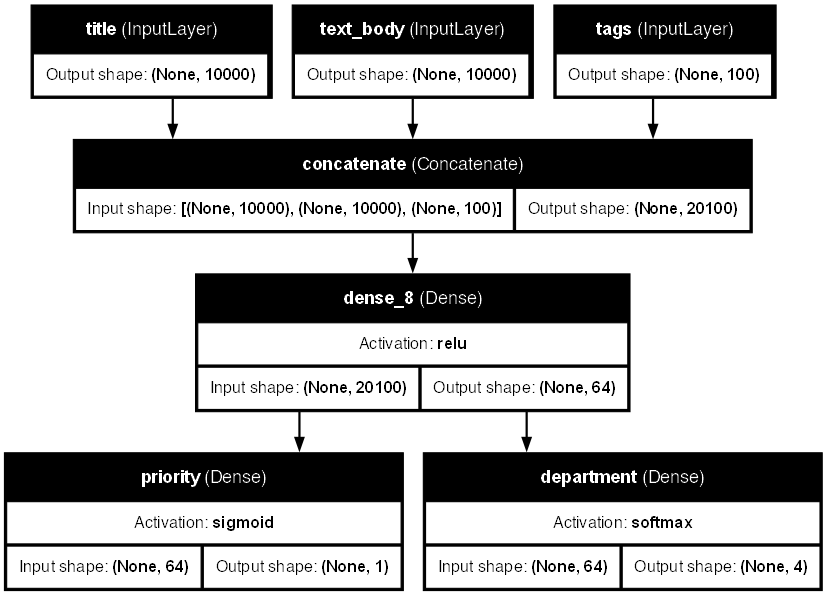

In [16]:
keras.utils.plot_model(model, to_file="ticket_classfier.png", 
                       dpi=80,
                       show_shapes=True, 
                       show_layer_names=True, 
                       show_layer_activations=True)

In [17]:
model.layers

[<InputLayer name=title, built=True>,
 <InputLayer name=text_body, built=True>,
 <InputLayer name=tags, built=True>,
 <Concatenate name=concatenate, built=True>,
 <Dense name=dense_8, built=True>,
 <Dense name=priority, built=True>,
 <Dense name=department, built=True>]

In [18]:
model.layers[3].input, model.layers[3].output

([<KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=title>,
  <KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=text_body>,
  <KerasTensor shape=(None, 100), dtype=float32, sparse=False, ragged=False, name=tags>],
 <KerasTensor shape=(None, 20100), dtype=float32, sparse=False, ragged=False, name=keras_tensor_14>)

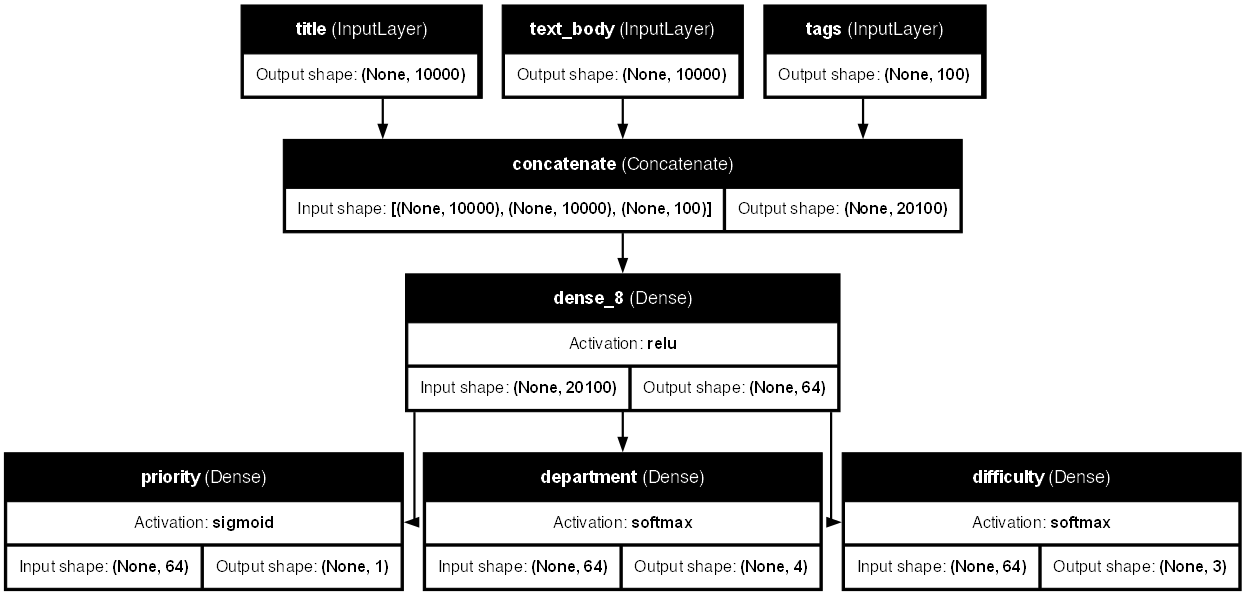

In [19]:
# resue intermediate layer outputs
features = model.layers[4].output
difficulty = layers.Dense(3, activation=activations.softmax, name="difficulty")(features)

new_model = keras.Model(
  inputs=[title, text_body, tags],
  outputs=[priority, department, difficulty])

keras.utils.plot_model(new_model, to_file="ticket_classfier_new.png", 
                       dpi=80,
                       show_shapes=True, 
                       show_layer_names=True, 
                       show_layer_activations=True)

## Model subclassing

In [20]:
class CustomerTicketModel(keras.Model):
  def __init__(self, num_departments):
    super().__init__()
    self.concat_layer = layers.Concatenate()
    self.mixing_layer = layers.Dense(64, activation=activations.relu)
    self.priority_scorer = layers.Dense(1, activation=activations.sigmoid)
    self.department_classfier = layers.Dense(num_departments, activation=activations.softmax)

  def call(self, inputs):
    title = inputs["title"]
    text_body = inputs["text_body"]
    tags = inputs["tags"]

    features = self.concat_layer([title, text_body, tags])
    features = self.mixing_layer(features)

    priority = self.priority_scorer(features)
    department = self.department_classfier(features)
    return priority, department

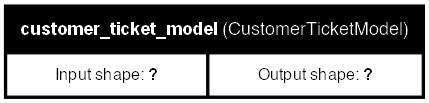

In [21]:
model = CustomerTicketModel(num_departments=4)
priority, department = model(
  {"title": title_data, "text_body": text_body_data, "tags": tags_data})

keras.utils.plot_model(model, to_file="ticket_classfier_model.png", 
                       dpi=80,
                       show_shapes=True, 
                       show_layer_names=True, 
                       show_layer_activations=True)

In [22]:
model.compile(optimizer=optimizers.RMSprop(),
              loss=[losses.mean_squared_error, losses.categorical_crossentropy],
              metrics=[[metrics.mean_absolute_error], [metrics.categorical_accuracy]])
model.fit({"title": title_data, "text_body": text_body_data, "tags": tags_data}, # dict
          [priority_data, department_data], # array
          epochs=1)
model.evaluate({"title": title_data, "text_body": text_body_data, "tags": tags_data},
               [priority_data, department_data])
priority_preds, department_preds = model.predict(
  {"title": title_data, "text_body": text_body_data, "tags": tags_data})
priority_preds, department_preds

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - categorical_accuracy: 0.2953 - categorical_crossentropy_loss: 37.2238 - loss: 37.5605 - mean_absolute_error: 0.5016 - mean_squared_error_loss: 0.3366
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.2484 - categorical_crossentropy_loss: 25.4372 - loss: 25.7800 - mean_absolute_error: 0.5080 - mean_squared_error_loss: 0.3428
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


(array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], shape=(1280, 1), dtype=float32),
 array([[5.3228592e-03, 9.9467719e-01, 2.2854694e-09, 2.2011655e-13],
        [2.7534574e-02, 9.7246540e-01, 1.0075070e-09, 4.3941337e-13],
        [6.0511315e-03, 9.9394882e-01, 5.4404059e-10, 4.4144464e-14],
        ...,
        [6.1143138e-02, 9.3885684e-01, 4.8964885e-09, 1.4683686e-12],
        [3.5319116e-02, 9.6468085e-01, 1.0356458e-09, 2.3909919e-13],
        [7.2661475e-03, 9.9273384e-01, 2.5106353e-10, 5.9041266e-14]],
       shape=(1280, 4), dtype=float32))

## Mixing

In [23]:
# a functional model includes a subclass model

class Classifier(keras.Model):
  def __init__(self, num_classes=2):
    super().__init__()
    if num_classes == 2:
      num_units = 1
      activation = activations.sigmoid
    else:
      num_units = num_classes
      activation = activations.softmax
    self.dense = layers.Dense(num_units, activation=activation)
  
  def call(self, inputs):
    return self.dense(inputs)
  
inputs = keras.Input(shape=(3,))
features = layers.Dense(64, activation=activations.relu)(inputs)
outpus = Classifier(num_classes=10)(features)       # <-----------
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ my_input            │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │        256 │ my_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 10)        │        650 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# a subclass model includes a functional model

inputs = keras.Input(shape=(64,))
outputs = layers.Dense(1, activation=activations.sigmoid)(inputs)
binary_classfier = keras.Model(inputs=inputs, outputs=outputs)

class MyModel(keras.Model):
  def __init__(self, num_classes=2):
    super().__init__()
    self.dense = layers.Dense(64, activation=activations.relu)
    self.classifer = binary_classfier   # <-----------
  
  def call(self, inputs):
    features = self.dense(inputs)
    return self.classifer(features)
  
model = MyModel()
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_9 (Functional)       │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

# Built-in train and eval loop

In [25]:
from keras.datasets import mnist

def get_mnist_model():
  inputs = keras.Input(shape=(28*28,))
  features = layers.Dense(512, activation=activations.relu)(inputs)
  features = layers.Dropout(0.5)(features)
  outpus = layers.Dense(10, activation=activations.softmax)(features)
  model = keras.Model(inputs, outpus)
  return model

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

val_size = 10000
train_images, val_images = train_images[val_size:], train_images[:val_size]
train_labels, val_labels = train_labels[val_size:], train_labels[:val_size]

model = get_mnist_model()
model.compile(optimizer=optimizers.RMSprop(),
              loss=losses.sparse_categorical_crossentropy,
              metrics=[metrics.sparse_categorical_accuracy])
model.fit(train_images, train_labels,
          epochs=3,
          validation_data=(val_images, val_labels))

test_metrics = model.evaluate(test_images, test_labels)
predictions = model.predict(test_images)
predictions

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.2951 - sparse_categorical_accuracy: 0.9121 - val_loss: 0.1457 - val_sparse_categorical_accuracy: 0.9595
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.1597 - sparse_categorical_accuracy: 0.9532 - val_loss: 0.1286 - val_sparse_categorical_accuracy: 0.9643
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.1311 - sparse_categorical_accuracy: 0.9645 - val_loss: 0.1154 - val_sparse_categorical_accuracy: 0.9697
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0995 - sparse_categorical_accuracy: 0.9728
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[1.6074951e-09, 8.9882060e-11, 4.7780709e-08, ..., 9.9999988e-01,
        2.0712480e-11, 2.2850392e-08],
       [2.7426614e-09, 4.3112973e-06, 9.9998021e-01, ..., 1.3095487e-16,
        5.8963502e-07, 7.0205308e-18],
       [2.2958480e-07, 9.9992335e-01, 2.8579716e-06, ..., 3.1654919e-05,
        1.2122385e-05, 1.0468087e-06],
       ...,
       [6.5722818e-13, 2.2625329e-10, 8.6899567e-12, ..., 1.5525632e-07,
        2.9809030e-07, 6.0780789e-05],
       [1.2355217e-07, 7.2714381e-09, 1.1629536e-10, ..., 6.7064146e-11,
        1.5370746e-05, 5.0230157e-11],
       [8.9043652e-09, 1.9657409e-14, 7.1369750e-09, ..., 3.2653406e-16,
        3.6269772e-13, 1.4688186e-11]], shape=(10000, 10), dtype=float32)

## Custom Metrics

In [26]:
# low-level usage

metric = metrics.SparseCategoricalAccuracy()
targets = [0,1,2]
predictions = [[1,0,0], [0,1,0], [0,0,1]]
metric.update_state(targets, predictions)
current_result = metric.result()
current_result

<tf.Tensor: shape=(), dtype=float32, numpy=1.0>

In [27]:
metric = metrics.Mean()
values = [0,1,2,3,4]
for value in values:
  metric.update_state(value)
metric.result()

<tf.Tensor: shape=(), dtype=float32, numpy=2.0>

In [28]:
# RMSE: root mean squared error

from typing import override


class RootMeanSquaredError(metrics.Metric):
  def __init__(self, name="rmse", **kwargs):
    super().__init__(name=name, **kwargs)
    # add_variable
    self.mse_sum = self.add_weight(name="mse_sum", initializer=initializers.zeros)
    self.total_samples = self.add_weight(name="total_samples", initializer=initializers.zeros, dtype=tf.int32)

  @override
  def update_state(self, y_true, y_pred, sample_weight=None):
    y_true = tf.one_hot(y_true, depth=tf.shape(y_pred)[1])
    mse = tf.reduce_sum(tf.square(y_true - y_pred))
    self.mse_sum.assign_add(mse)
    num_samples = tf.shape(y_pred)[0]
    self.total_samples.assign_add(num_samples)

  @override
  def result(self):
    return tf.sqrt(self.mse_sum / tf.cast(self.total_samples, tf.float32))
  
  @override
  def reset_state(self):
    self.mse_sum.assign(0.)
    self.total_samples.assign(0)

In [29]:
model = get_mnist_model()
model.compile(optimizer=optimizers.RMSprop(),
              loss=losses.sparse_categorical_crossentropy,
              metrics=[metrics.sparse_categorical_accuracy, RootMeanSquaredError()])
model.fit(train_images, train_labels,
          epochs=3,
          validation_data=(val_images, val_labels))

test_metrics = model.evaluate(test_images, test_labels)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.2941 - rmse: 0.3626 - sparse_categorical_accuracy: 0.9139 - val_loss: 0.1487 - val_rmse: 0.2526 - val_sparse_categorical_accuracy: 0.9593
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.1580 - rmse: 0.2651 - sparse_categorical_accuracy: 0.9535 - val_loss: 0.1155 - val_rmse: 0.2231 - val_sparse_categorical_accuracy: 0.9666
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.1301 - rmse: 0.2374 - sparse_categorical_accuracy: 0.9640 - val_loss: 0.0965 - val_rmse: 0.2024 - val_sparse_categorical_accuracy: 0.9735
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0914 - rmse: 0.2005 - sparse_categorical_accuracy: 0.9736


## Callbacks

In [30]:
keras_model_checkpoint_path = 'checkpoint.keras'
callback_list = [
  callbacks.EarlyStopping(monitor="val_sparse_categorical_accuracy", mode='max', patience=2),
  callbacks.ModelCheckpoint(filepath=keras_model_checkpoint_path, monitor="val_sparse_categorical_accuracy", mode='max', save_best_only=True)
]

model = get_mnist_model()
model.compile(optimizer=optimizers.RMSprop(),
              loss=losses.sparse_categorical_crossentropy,
              metrics=[metrics.sparse_categorical_accuracy])
model.fit(train_images, train_labels,
          epochs=10,
          callbacks=callback_list,
          validation_data=(val_images, val_labels))

test_metrics = model.evaluate(test_images, test_labels)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.2938 - sparse_categorical_accuracy: 0.9126 - val_loss: 0.1418 - val_sparse_categorical_accuracy: 0.9593
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.1602 - sparse_categorical_accuracy: 0.9545 - val_loss: 0.1138 - val_sparse_categorical_accuracy: 0.9681
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.1296 - sparse_categorical_accuracy: 0.9637 - val_loss: 0.1021 - val_sparse_categorical_accuracy: 0.9707
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.1131 - sparse_categorical_accuracy: 0.9683 - val_loss: 0.0986 - val_sparse_categorical_accuracy: 0.9731
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.1016 - sparse_categorical_accuracy: 0.9717 - val_loss: 0.0894 - val_sparse_categorical_accuracy: 0.9772
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0894 - sparse_categorical_accuracy: 0.9761 - val_loss: 0.0890 - val_sparse_categorical_accu

In [31]:
# reload model
model_reload = keras.models.load_model(keras_model_checkpoint_path)
model_reload.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,102 (3.11 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 407,052 (1.55 MB)

#### Custom callbacks

In [32]:
class LossHistory(callbacks.Callback):
  @override
  def on_train_begin(self, logs=None):
    self.per_batch_losses = []

  @override
  def on_batch_end(self, batch, logs=None):
    if logs is not None:
      self.per_batch_losses.append(logs.get("loss"))
  
  @override
  def on_epoch_end(self, epoch, logs=None):
    plt.clf()
    plt.plot(range(len(self.per_batch_losses)), self.per_batch_losses, label='batch loss')
    plt.xlabel(f'batch in epoch {epoch}')
    plt.ylabel('loss')
    plt.legend()
    # plt.savefig(f'loss_history_{epoch}.png')
    plt.show()

    self.per_batch_losses = []

Epoch 1/3
1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4606 - sparse_categorical_accuracy: 0.8610

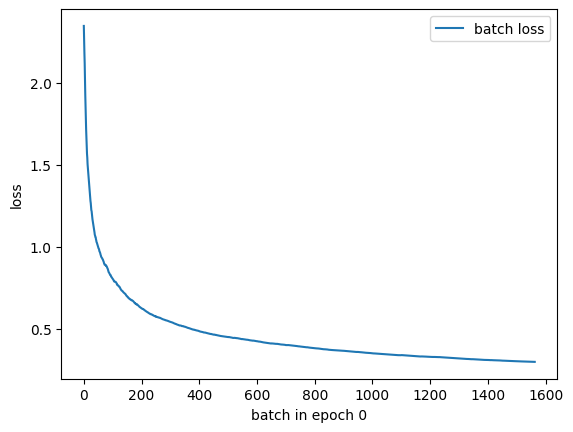

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.2997 - sparse_categorical_accuracy: 0.9112 - val_loss: 0.1567 - val_sparse_categorical_accuracy: 0.9531
Epoch 2/3
1559/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1623 - sparse_categorical_accuracy: 0.9540

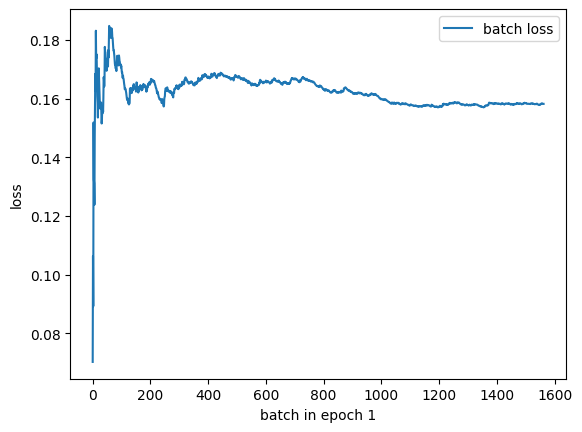

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.1582 - sparse_categorical_accuracy: 0.9545 - val_loss: 0.1161 - val_sparse_categorical_accuracy: 0.9686
Epoch 3/3
1561/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1330 - sparse_categorical_accuracy: 0.9630

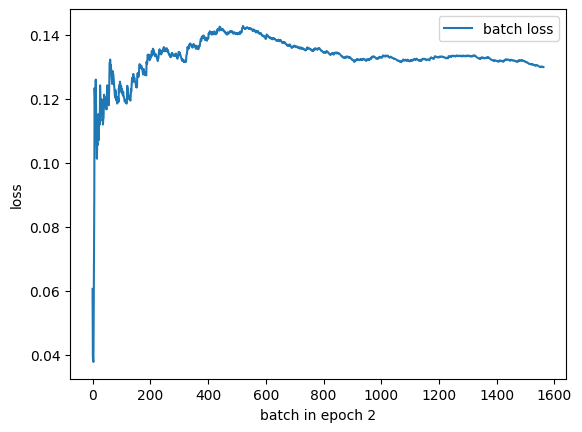

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.1299 - sparse_categorical_accuracy: 0.9630 - val_loss: 0.1096 - val_sparse_categorical_accuracy: 0.9721
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0999 - sparse_categorical_accuracy: 0.9740


In [33]:
model = get_mnist_model()
model.compile(optimizer=optimizers.RMSprop(),
              loss=losses.sparse_categorical_crossentropy,
              metrics=[metrics.sparse_categorical_accuracy])
model.fit(train_images, train_labels,
          epochs=3,
          callbacks=[LossHistory()],
          validation_data=(val_images, val_labels))

test_metrics = model.evaluate(test_images, test_labels)

## TensorBoard: monitoring, visualization

In [34]:
from util.tf import get_run_logdir

model = get_mnist_model()
model.compile(optimizer=optimizers.RMSprop(),
              loss=losses.sparse_categorical_crossentropy,
              metrics=[metrics.sparse_categorical_accuracy])

_run_logdir = get_run_logdir('../../data/tf_logs')
print(_run_logdir)
tensorboard_callback = callbacks.TensorBoard(
  log_dir=_run_logdir)
model.fit(train_images, train_labels,
          epochs=3,
          callbacks=[tensorboard_callback],             # <------------
          validation_data=(val_images, val_labels))

test_metrics = model.evaluate(test_images, test_labels)

..\..\data\tf_logs\run_2025_10_15_13_32_55
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.2949 - sparse_categorical_accuracy: 0.9122 - val_loss: 0.1403 - val_sparse_categorical_accuracy: 0.9586
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.1587 - sparse_categorical_accuracy: 0.9550 - val_loss: 0.1216 - val_sparse_categorical_accuracy: 0.9657
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.1282 - sparse_categorical_accuracy: 0.9643 - val_loss: 0.0997 - val_sparse_categorical_accuracy: 0.9728
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0875 - sparse_categorical_accuracy: 0.9743


In [35]:
# %load_ext tensorboard
# %tensorboard --logdir {_run_logdir}

# Custom train and eval loop

In [36]:
# a complete train and eval loop


model = get_mnist_model()

loss_fn = losses.SparseCategoricalCrossentropy()
optimizer = optimizers.RMSprop()
metric_list = [metrics.SparseCategoricalAccuracy()]
loss_tracking_metric = metrics.Mean()


def train_step(inputs, targets):
  with tf.GradientTape() as tape:
    predictions = model(inputs, training=True)
    loss = loss_fn(targets, predictions)
  gradients = tape.gradient(loss, model.trainable_weights)
  optimizer.apply_gradients(zip(gradients, model.trainable_weights))

  logs = {}
  for metric in metric_list:
    metric.update_state(targets, predictions)
    logs[metric.name] = metric.result()

  loss_tracking_metric.update_state(loss)
  logs['loss'] = loss_tracking_metric.result()
  return logs


def reset_metrics():
  for metric in metric_list:
    metric.reset_state()
  loss_tracking_metric.reset_state()


# train loop: fit()
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_images, train_labels))  # MNIST
train_dataset = train_dataset.batch(128)  # as batch
epochs = 3
for epoch in range(epochs):
  reset_metrics()
  for inputs_batch, targets_batch in train_dataset:
    logs = train_step(inputs_batch, targets_batch)
  print(f"train logs at epoch {epoch}:")
  for k, v in logs.items():
    print(f"...{k}: {v:.4f}")

train logs at epoch 0:
...sparse_categorical_accuracy: 0.8953
...loss: 0.3569
train logs at epoch 1:
...sparse_categorical_accuracy: 0.9485
...loss: 0.1730
train logs at epoch 2:
...sparse_categorical_accuracy: 0.9617
...loss: 0.1309


In [37]:
# eval: evaluate()
@tf.function  # compile to graph
def test_step(inputs, targets):
  predictions = model(inputs, training=False)
  loss = loss_fn(targets, predictions)

  logs = {}
  for metric in metric_list:
    metric.update_state(targets, predictions)
    logs["val_" + metric.name] = metric.result()
  loss_tracking_metric.update_state(loss)
  logs['val_loss'] = loss_tracking_metric.result()
  return logs


val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
val_dataset = val_dataset.batch(128)
reset_metrics()
for inputs_batch, targets_batch in val_dataset:
  logs = test_step(inputs_batch, targets_batch)
print('eval logs:')
for k, v in logs.items():
  print(f"...{k}: {v:.4f}")

eval logs:
...val_sparse_categorical_accuracy: 0.9670
...val_loss: 0.1130


Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - sparse_categorical_accuracy: 0.9131 - loss: 0.2934
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - sparse_categorical_accuracy: 0.9536 - loss: 0.1577
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - sparse_categorical_accuracy: 0.9637 - loss: 0.1292


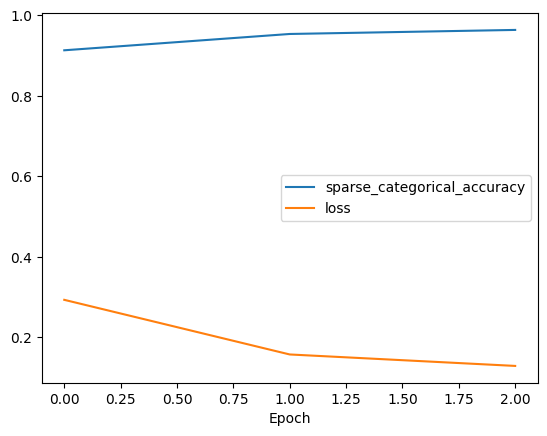

In [38]:
# use fit(): override train_step() in Model

from util.tf import plot_history


class CustomModel(keras.Model):
  @override  # Trainer
  def train_step(self, data):  # called by fit() for every batch
    inputs, targets = data
    with tf.GradientTape() as tape:
      predictions = self(inputs, training=True)
      loss = self.compute_loss(y=targets, y_pred=predictions)

    gradients = tape.gradient(loss, self.trainable_weights)
    self.optimizer.apply(gradients, self.trainable_weights)

    for metric in self.metrics:
      if metric.name == "loss":
        metric.update_state(loss)
      else:
        metric.update_state(targets, predictions)
    return {m.name: m.result() for m in self.metrics}

#   # @override # Layer
#   # @property
#   # def metrics(self):
#   #   return [loss_tracker]


def get_model():
  inputs = keras.Input(shape=(28*28,))
  features = layers.Dense(512, activation=activations.relu)(inputs)
  features = layers.Dropout(0.5)(features)
  outputs = layers.Dense(10, activation=activations.softmax)(features)
  model = CustomModel(inputs, outputs)

  model.compile(optimizer=optimizers.RMSprop(),
                loss=losses.SparseCategoricalCrossentropy(),  # after: compute_loss()
                # after: compute_metrics(), metrics
                metrics=[metrics.SparseCategoricalAccuracy()]
                )
  return model


model = get_model()
history = model.fit(train_images, train_labels, epochs=3)
plot_history(history)

# Cleanup

In [39]:
import os
os.remove("ticket_classfier.png")
os.remove("ticket_classfier_new.png")
os.remove("ticket_classfier_model.png")
os.remove(keras_model_checkpoint_path)